<a href="https://colab.research.google.com/github/Mousamjha/pytorch_deep_learning/blob/main/rice_type_binary_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [44]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [45]:
data_df = pd.read_csv("/content/riceClassification.csv")
data_df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [46]:
data_df.isnull().sum()

,0
id,0
Area,0
MajorAxisLength,0
MinorAxisLength,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Perimeter,0
Roundness,0


In [47]:
data_df.drop(['id'], inplace=True, axis=1)

In [48]:
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [49]:
original_data = data_df.copy()

#normalize columns data by dividing each columns max value
for col in data_df.columns:
  data_df[col] = data_df[col]/data_df[col].max()

In [50]:
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [51]:
print(data_df["Area"].max())
print(data_df["Area"].min())


1.0
0.24701273261508325


In [52]:
data_df['Class'].value_counts()

,count
Class,
1.0,9985
0.0,8200


In [53]:
X = np.array(data_df.iloc[:, :-1])
y = np.array(data_df.iloc[:, -1])

In [54]:
y

array([1., 1., 1., ..., 0., 0., 0.])

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,           shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42, shuffle=True)

In [56]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (14548, 10)
y_train shape: (14548,)
X_val shape: (1818, 10)
y_val shape: (1818,)
X_test shape: (1819, 10)
y_test shape: (1819,)


In [57]:
class dataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y, dtype=torch.float32).to(device)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [58]:
# Create training, testing and validation data

training_data = dataset(X_train, y_train)
testing_data = dataset(X_test, y_test)
validation_data = dataset(X_val, y_val)

In [59]:
BATCH_SIZE = 8

train_dataloader = DataLoader(training_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(testing_data, batch_size=BATCH_SIZE, shuffle=True)
validation_dataloader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=True)

In [60]:
# for x, y in train_dataloader:
#     print(x)
#     print('='*30)
#     print(y)
#     break

In [61]:
HIDDEN_NEURONS = 32

class RiceModal(nn.Module):

    def __init__(self):
        super(RiceModal, self).__init__()

        self.input_layer = nn.Linear(X.shape[1], HIDDEN_NEURONS)
        self.linear = nn.Linear(HIDDEN_NEURONS, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.input_layer(x)
        x = self.linear(x)
        x = self.sigmoid(x)
        return x


rice_model = RiceModal().to(device)


In [62]:
rice_model

RiceModal(
  (input_layer): Linear(in_features=10, out_features=32, bias=True)
  (linear): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [63]:
summary(rice_model, (X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 32]             352
            Linear-2                    [-1, 1]              33
           Sigmoid-3                    [-1, 1]               0
Total params: 385
Trainable params: 385
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [64]:
criterion = nn.BCELoss()
optimizer = Adam(rice_model.parameters(), lr = 1e-3)

In [65]:
total_loss_train_plot = []
total_loss_val_plot = []
total_acc_train_plot = []
total_acc_val_plot = []

In [66]:
epochs = 10

for epoch in range(epochs):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val = 0

    for data in train_dataloader:
        inputs, labels = data
        prediction = rice_model(inputs).squeeze(1)

        batch_loss = criterion(prediction, labels)

        total_loss_train += batch_loss.item()

        acc = ((prediction.round() == labels)).sum().item()
        total_acc_train += acc

        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    with torch.no_grad():
        for data in validation_dataloader:
            inputs, labels = data
            prediction = rice_model(inputs).squeeze(1)

            batch_loss = criterion(prediction, labels)

            total_loss_val += batch_loss.item()

            acc = ((prediction.round() == labels)).sum(). item()
            total_acc_val += acc

    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_acc_train_plot.append(round(total_acc_train/training_data.__len__() * 100, 4))
    total_loss_val_plot.append(round(total_loss_val/1000, 4))
    total_acc_val_plot.append(round(total_acc_val/validation_data.__len__() * 100, 4))

    print(f"Epoch: {epoch+1}")
    print(f"Train Loss: {round(total_loss_train/1000, 4)}")
    print(f"Train Accuracy: {round(total_acc_train/training_data.__len__() * 100, 4)}")
    print(f"Val Loss: {round(total_loss_val/1000, 4)}")
    print(f"Val Accuracy: {round(total_acc_val/validation_data.__len__() * 100, 4)}")
    print('='*30)


Epoch: 1
Train Loss: 0.4363
Train Accuracy: 95.7864
Val Loss: 0.0126
Val Accuracy: 99.1749
Epoch: 2
Train Loss: 0.1004
Train Accuracy: 98.4878
Val Loss: 0.008
Val Accuracy: 99.0099
Epoch: 3
Train Loss: 0.0823
Train Accuracy: 98.5909
Val Loss: 0.0071
Val Accuracy: 99.2299
Epoch: 4
Train Loss: 0.0789
Train Accuracy: 98.5565
Val Loss: 0.0066
Val Accuracy: 99.2299
Epoch: 5
Train Loss: 0.0778
Train Accuracy: 98.6252
Val Loss: 0.0063
Val Accuracy: 99.2849
Epoch: 6
Train Loss: 0.0783
Train Accuracy: 98.529
Val Loss: 0.0062
Val Accuracy: 99.1199
Epoch: 7
Train Loss: 0.077
Train Accuracy: 98.5703
Val Loss: 0.0065
Val Accuracy: 99.1199
Epoch: 8
Train Loss: 0.0782
Train Accuracy: 98.5771
Val Loss: 0.0079
Val Accuracy: 98.8999
Epoch: 9
Train Loss: 0.0766
Train Accuracy: 98.5634
Val Loss: 0.0061
Val Accuracy: 99.1749
Epoch: 10
Train Loss: 0.0771
Train Accuracy: 98.5428
Val Loss: 0.0065
Val Accuracy: 99.1199


In [67]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0
    for data in test_dataloader:
        inputs, labels = data
        prediction = rice_model((inputs)).squeeze(1)

        batch_loss_test = criterion(prediction, labels).item()

        total_loss_test += batch_loss_test

        acc = ((prediction.round()) == labels).sum().item()
        total_acc_test += acc

    print(f"Test Loss: {round(total_loss_test/1000, 4)}")
    print(f"Test Accuracy: {round(total_acc_test/testing_data.__len__() * 100, 4)}")

Test Loss: 0.0116
Test Accuracy: 98.1858


Text(0.5, 1.0, 'Accuracy')

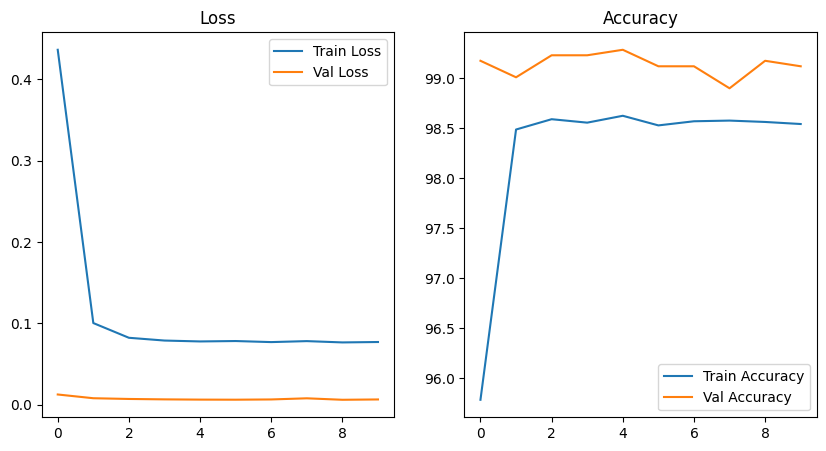

In [71]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
axs[0].plot(total_loss_train_plot, label="Train Loss")
axs[0].plot(total_loss_val_plot, label="Val Loss")
axs[0].legend()
axs[0].set_title("Loss")

axs[1].plot(total_acc_train_plot, label="Train Accuracy")
axs[1].plot(total_acc_val_plot, label="Val Accuracy")
axs[1].legend()
axs[1].set_title("Accuracy")